# Caso práctico Hike — Análisis de datos de marketing y ventas

Ecommerce de productos para hogar y decoración. 4 tablas:
- `google_ads.csv`: pauta en Google Ads (semanal, por campaña).
- `meta_ads.csv`: pauta en Meta Ads (semanal, por campaña).
- `ventas.csv`: performance comercial (semanal, por producto).
- `stock.csv`: catálogo con stock actual.

Este notebook:
1. Explora cada tabla (EDA).
2. Detecta inconsistencias de naming, rangos, tipos.
3. Normaliza y unifica los datos.
4. Calcula métricas derivadas (CPC, CPM, CTR, ROAS).
5. Analiza performance por canal, campaña, categoría.
6. Cruza pauta con ventas y stock.
7. Analiza AOV por categoría y top productos individuales.
8. Analiza eficiencia por click (CPC vs ROAS).
9. Analiza estacionalidad con calendario comercial argentino.
10. Incluye una mirada histórica de Google (2024-2026).
11. Detecta stock crítico y productos zombie sin ventas.
12. Exporta tablas limpias para el dashboard de Looker Studio.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

# Configuración visual
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Paths
DATA_DIR = Path(".")
CLEAN_DIR = DATA_DIR / "clean"
CHARTS_DIR = DATA_DIR / "charts"
CLEAN_DIR.mkdir(exist_ok=True)
CHARTS_DIR.mkdir(exist_ok=True)

print("Entorno listo.")

Entorno listo.


## 1. Cargar los 4 datasets

In [2]:
google = pd.read_csv(DATA_DIR / "google_ads.csv", parse_dates=["week"])
meta = pd.read_csv(DATA_DIR / "meta_ads.csv", parse_dates=["date_week"])
ventas = pd.read_csv(DATA_DIR / "ventas.csv", parse_dates=["week_start"])
stock = pd.read_csv(DATA_DIR / "stock.csv")

print(f"google_ads: {google.shape}  | rango: {google['week'].min().date()} → {google['week'].max().date()}")
print(f"meta_ads:   {meta.shape}    | rango: {meta['date_week'].min().date()} → {meta['date_week'].max().date()}")
print(f"ventas:     {ventas.shape}  | rango: {ventas['week_start'].min().date()} → {ventas['week_start'].max().date()}")
print(f"stock:      {stock.shape}   | sin dimensión temporal")

google_ads: (1099, 8)  | rango: 2024-01-01 → 2026-12-28
meta_ads:   (728, 6)    | rango: 2025-01-06 → 2026-12-28
ventas:     (2912, 5)  | rango: 2025-01-06 → 2026-12-28
stock:      (38, 4)   | sin dimensión temporal


## 2. EDA inicial — ¿qué tiene cada tabla?

In [3]:
print("=== GOOGLE ADS ===")
print(google.dtypes)
print(google.head(3))

=== GOOGLE ADS ===
week             datetime64[ns]
campaign_name            object
cost                    float64
impressions               int64
clicks                    int64
conv_value              float64
views                     int64
leads                     int64
dtype: object
        week campaign_name     cost  impressions  clicks  conv_value  views  leads
0 2024-01-01        Aromas 3,012.42        93347    1610   16,996.48   6140    189
1 2024-01-01          Baño 3,131.59        84198    1507    9,114.77   8018    100
2 2024-01-01        Cocina 1,332.76        38100     672    7,239.30   6442     36


In [4]:
print("=== META ADS ===")
print(meta.dtypes)
print(meta.head(3))

=== META ADS ===
date_week         datetime64[ns]
campaign_name             object
spend                    float64
impressions                int64
link_clicks                int64
purchase_value           float64
dtype: object
   date_week campaign_name    spend  impressions  link_clicks  purchase_value
0 2025-01-06        Cocina 4,050.45       100823         2132       18,052.69
1 2025-01-06          Baño 3,011.60        66923         1568        9,090.03
2 2025-01-06          Deco 4,645.09       108115         2426       12,320.08


In [5]:
print("=== VENTAS ===")
print(ventas.dtypes)
print(ventas.head(3))

=== VENTAS ===
week_start           datetime64[ns]
producto                     object
categoria                    object
unidades_vendidas             int64
ingreso_total               float64
dtype: object
  week_start                   producto categoria  unidades_vendidas  ingreso_total
0 2025-01-06  Set de Bowls Mediterráneo    cocina                 10      40,244.06
1 2025-01-06     Tabla de Madera Olivia    cocina                 17      99,652.26
2 2025-01-06     Porta Utensilios Cobre    cocina                 20      59,752.99


In [6]:
print("=== STOCK ===")
print(stock.dtypes)
print(stock.head(3))

=== STOCK ===
producto     object
sku          object
stock         int64
categoria    object
dtype: object
                    producto      sku  stock categoria
0  Set de Bowls Mediterráneo  COC-001     84    cocina
1     Tabla de Madera Olivia  COC-002     61    cocina
2     Porta Utensilios Cobre  COC-003    120    cocina


## 3. Diagnóstico de calidad de datos

In [7]:
print("NULLS por tabla:")
for name, df in [("google", google), ("meta", meta), ("ventas", ventas), ("stock", stock)]:
    n = df.isna().sum().sum()
    print(f"  {name}: {n} nulls")

print("\nDUPLICADOS:")
print(f"  google (week+campaign): {google.duplicated(subset=['week', 'campaign_name']).sum()}")
print(f"  meta (date_week+campaign): {meta.duplicated(subset=['date_week', 'campaign_name']).sum()}")
print(f"  ventas (week+producto): {ventas.duplicated(subset=['week_start', 'producto']).sum()}")
print(f"  stock (sku): {stock.duplicated(subset=['sku']).sum()}")

print("\nCAMPAÑAS / CATEGORÍAS:")
print(f"  Google: {sorted(google.campaign_name.unique())}")
print(f"  Meta:   {sorted(meta.campaign_name.unique())}")
print(f"  Ventas: {sorted(ventas.categoria.unique())}")
print(f"  Stock:  {sorted(stock.categoria.unique())}")

NULLS por tabla:
  google: 0 nulls
  meta: 0 nulls
  ventas: 0 nulls
  stock: 0 nulls

DUPLICADOS:
  google (week+campaign): 0
  meta (date_week+campaign): 0
  ventas (week+producto): 0
  stock (sku): 0

CAMPAÑAS / CATEGORÍAS:
  Google: ['Aromas', 'Baño', 'Cocina', 'Deco', 'Jardín', 'Mesa', 'Sillones']
  Meta:   ['Aromas', 'Baño', 'Cocina', 'Deco', 'Jardín', 'Mesa', 'Sillones']
  Ventas: ['aromas', 'baño', 'cocina', 'deco', 'jardin', 'mesa', 'sillones']
  Stock:  ['aromas', 'baño', 'cocina', 'deco', 'jardin', 'mesa', 'sillones']


**Hallazgos:**

1. **Rangos de fecha distintos**: Google 2024-01-01 → 2026-12-28 (3 años). Meta y ventas 2025-01-06 → 2026-12-28 (2 años). Para comparar canales usamos el overlap; para análisis histórico de Google usamos el rango completo.
2. **Naming inconsistente**: ads usan mayúsculas con acentos (`Baño`, `Jardín`); ventas y stock usan minúsculas sin acentos (`baño`, `jardin`).
3. **Sin nulls, sin duplicados, sin divisiones por cero** — data limpia estructuralmente.
4. **7 categorías** consistentes en todas las tablas.
5. **Todas las semanas son lunes** — período de 7 días corriendo de lunes a domingo.

## 4. Normalización y unificación

In [8]:
def normalize_name(s):
    if pd.isna(s):
        return s
    s = s.lower()
    for k, v in {"á": "a", "é": "e", "í": "i", "ó": "o", "ú": "u", "ñ": "n"}.items():
        s = s.replace(k, v)
    return s

google_clean = google.rename(columns={
    "week": "week", "campaign_name": "campaign", "cost": "cost",
    "impressions": "impressions", "clicks": "clicks", "conv_value": "revenue",
}).copy()
google_clean["channel"] = "Google Ads"
google_clean["campaign"] = google_clean["campaign"].apply(normalize_name)

meta_clean = meta.rename(columns={
    "date_week": "week", "campaign_name": "campaign", "spend": "cost",
    "impressions": "impressions", "link_clicks": "clicks", "purchase_value": "revenue",
}).copy()
meta_clean["channel"] = "Meta Ads"
meta_clean["campaign"] = meta_clean["campaign"].apply(normalize_name)

common_cols = ["week", "channel", "campaign", "cost", "impressions", "clicks", "revenue"]
master_ads = pd.concat([google_clean[common_cols], meta_clean[common_cols]], ignore_index=True)
master_ads = master_ads.sort_values(["week", "channel", "campaign"]).reset_index(drop=True)

# Normalizamos también ventas y stock
ventas = ventas.copy()
ventas["categoria"] = ventas["categoria"].apply(normalize_name)
stock = stock.copy()
stock["categoria"] = stock["categoria"].apply(normalize_name)

print(f"master_ads: {master_ads.shape}")
print("Categorías unificadas:",
      sorted(set(master_ads["campaign"]) | set(ventas["categoria"]) | set(stock["categoria"])))

master_ads: (1827, 7)
Categorías unificadas: ['aromas', 'bano', 'cocina', 'deco', 'jardin', 'mesa', 'sillones']


## 5. Métricas derivadas

- **CPC** = cost / clicks
- **CPM** = (cost / impressions) × 1000
- **CTR** = clicks / impressions
- **ROAS** = revenue / cost

In [9]:
def add_derived_metrics(df):
    df = df.copy()
    df["cpc"] = df["cost"] / df["clicks"].replace(0, np.nan)
    df["cpm"] = df["cost"] / df["impressions"].replace(0, np.nan) * 1000
    df["ctr"] = df["clicks"] / df["impressions"].replace(0, np.nan)
    df["roas"] = df["revenue"] / df["cost"].replace(0, np.nan)
    return df

master_ads = add_derived_metrics(master_ads)
master_ads.describe()

,week,cost,impressions,clicks,revenue,cpc,cpm,ctr,roas
count,1827,"1,827.00","1,827.00","1,827.00","1,827.00","1,827.00","1,827.00","1,827.00","1,827.00"
mean,2025-09-11 21:58:37.241379328,"3,232.39","83,088.25","1,659.87","13,900.77",1.99,39.45,0.02,4.34
min,2024-01-01 00:00:00,"1,191.11","24,464.00",381.00,"2,000.34",1.32,31.26,0.01,1.21
25%,2025-02-17 00:00:00,"2,441.82","61,843.50","1,229.00","9,013.30",1.88,36.85,0.02,3.15
50%,2025-09-29 00:00:00,"3,126.45","79,444.00","1,593.00","13,082.47",1.92,38.14,0.02,4.23
75%,2026-05-18 00:00:00,"3,876.62","101,184.00","2,023.50","17,917.83",1.97,42.06,0.02,5.45
max,2026-12-28 00:00:00,"7,612.58","205,751.00","4,114.00","46,333.80",4.28,54.84,0.02,7.69
std,NaN,"1,093.08","30,253.98",617.85,"6,537.24",0.30,3.86,0.00,1.48


## 6. KPIs globales por canal (período comparable: 2025-01-06 en adelante)

In [10]:
OVERLAP_START = pd.Timestamp("2025-01-06")
master_overlap = master_ads[master_ads["week"] >= OVERLAP_START].copy()

kpis_by_channel = master_overlap.groupby("channel").agg(
    cost=("cost", "sum"),
    impressions=("impressions", "sum"),
    clicks=("clicks", "sum"),
    revenue=("revenue", "sum"),
).assign(
    cpc=lambda d: d["cost"] / d["clicks"],
    cpm=lambda d: d["cost"] / d["impressions"] * 1000,
    ctr=lambda d: d["clicks"] / d["impressions"],
    roas=lambda d: d["revenue"] / d["cost"],
).round(3)
print(kpis_by_channel)

                   cost  impressions   clicks       revenue  cpc   cpm  ctr  roas
channel                                                                          
Google Ads 2,631,117.19     71353753  1382217 11,634,810.95 1.90 36.87 0.02  4.42
Meta Ads   2,230,391.37     53732806  1161873  8,865,791.97 1.92 41.51 0.02  3.98


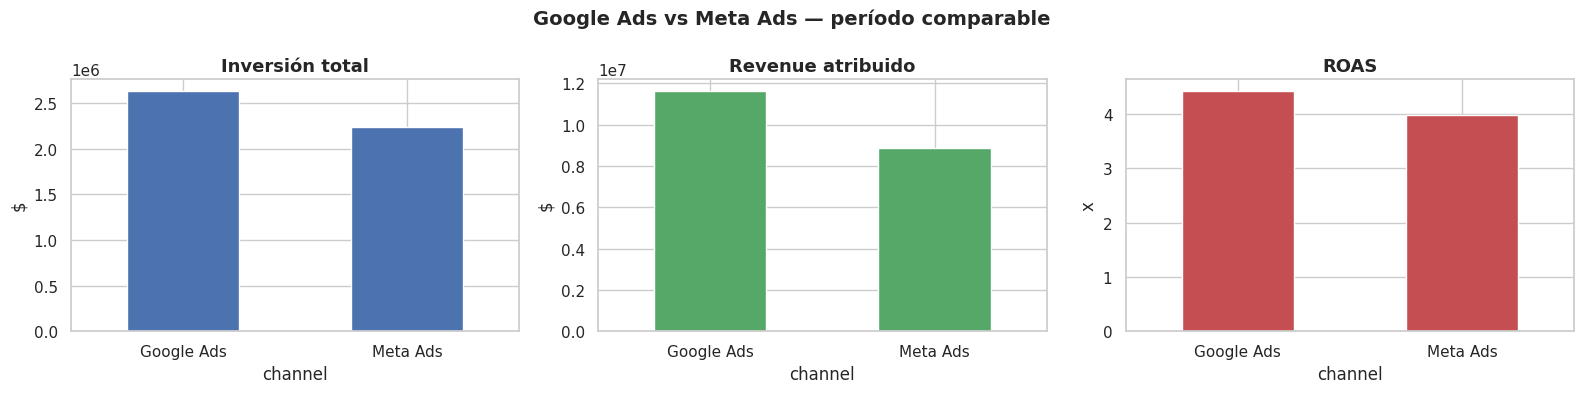

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
kpis_by_channel[["cost"]].plot(kind="bar", ax=axes[0], color="#4c72b0", legend=False)
axes[0].set_title("Inversión total"); axes[0].set_ylabel("$"); axes[0].tick_params(axis='x', rotation=0)

kpis_by_channel[["revenue"]].plot(kind="bar", ax=axes[1], color="#55a868", legend=False)
axes[1].set_title("Revenue atribuido"); axes[1].set_ylabel("$"); axes[1].tick_params(axis='x', rotation=0)

kpis_by_channel[["roas"]].plot(kind="bar", ax=axes[2], color="#c44e52", legend=False)
axes[2].set_title("ROAS"); axes[2].set_ylabel("x"); axes[2].tick_params(axis='x', rotation=0)

plt.suptitle("Google Ads vs Meta Ads — período comparable", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(CHARTS_DIR / "01_overview_canales.png", dpi=120, bbox_inches="tight")
plt.show()

## 7. Evolución temporal semanal

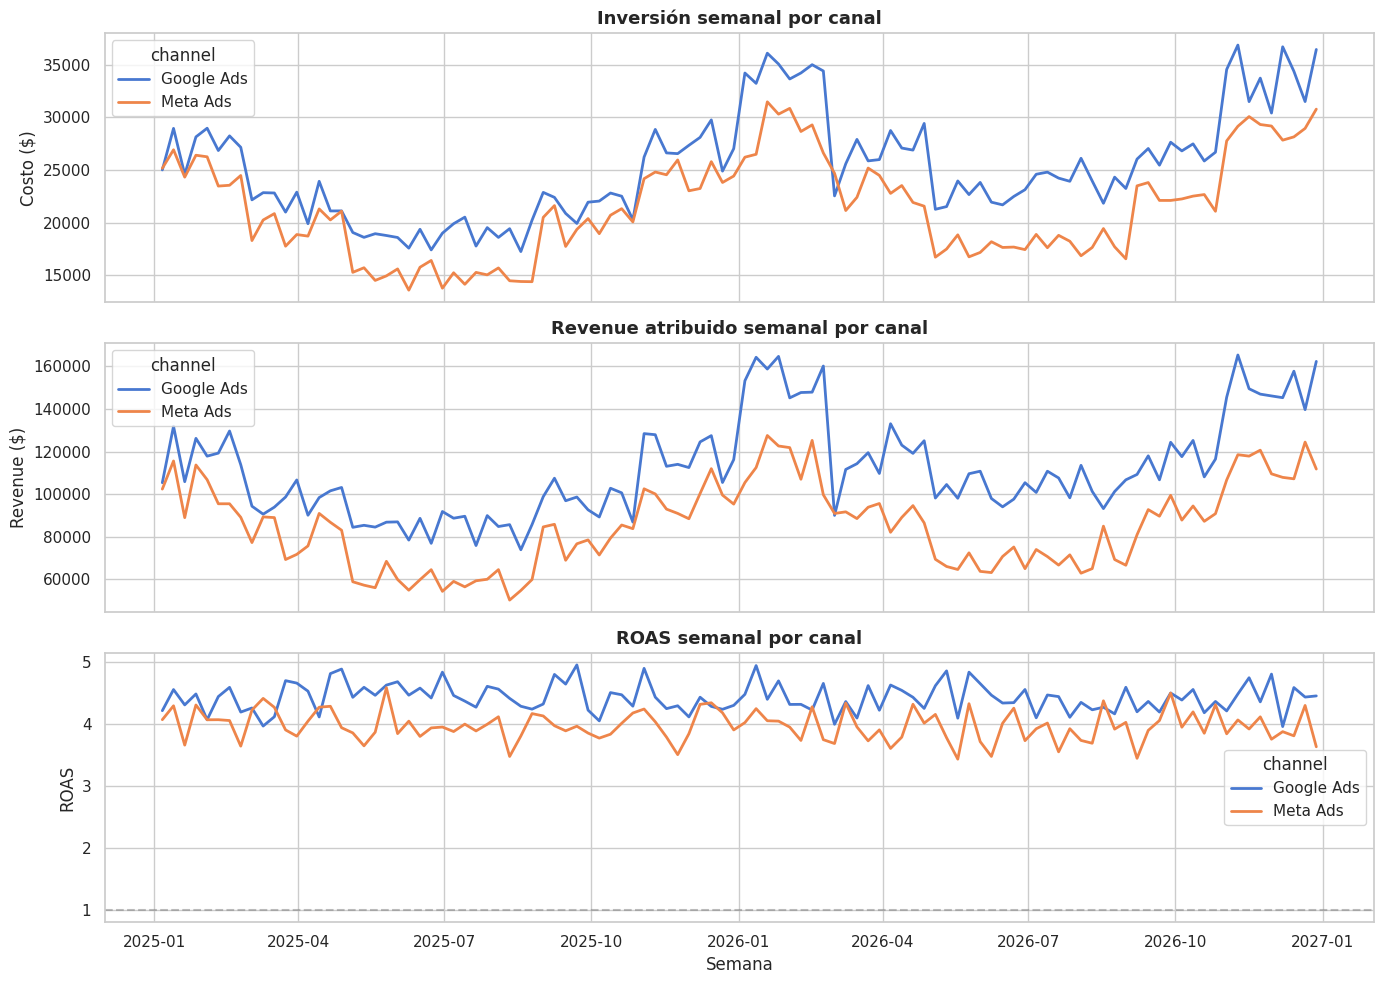

In [12]:
weekly_channel = master_overlap.groupby(["week", "channel"]).agg(
    cost=("cost", "sum"), revenue=("revenue", "sum"),
).reset_index()
weekly_channel["roas"] = weekly_channel["revenue"] / weekly_channel["cost"]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
sns.lineplot(data=weekly_channel, x="week", y="cost", hue="channel", ax=axes[0], linewidth=2)
axes[0].set_title("Inversión semanal por canal"); axes[0].set_ylabel("Costo ($)")
sns.lineplot(data=weekly_channel, x="week", y="revenue", hue="channel", ax=axes[1], linewidth=2)
axes[1].set_title("Revenue atribuido semanal por canal"); axes[1].set_ylabel("Revenue ($)")
sns.lineplot(data=weekly_channel, x="week", y="roas", hue="channel", ax=axes[2], linewidth=2)
axes[2].axhline(y=1, color="gray", linestyle="--", alpha=0.5)
axes[2].set_title("ROAS semanal por canal"); axes[2].set_ylabel("ROAS"); axes[2].set_xlabel("Semana")
plt.tight_layout()
plt.savefig(CHARTS_DIR / "02_evolucion_semanal.png", dpi=120, bbox_inches="tight")
plt.show()

## 8. Performance por campaña / categoría

In [13]:
by_campaign = master_overlap.groupby(["channel", "campaign"]).agg(
    cost=("cost", "sum"), impressions=("impressions", "sum"),
    clicks=("clicks", "sum"), revenue=("revenue", "sum"),
).assign(
    cpc=lambda d: d["cost"] / d["clicks"],
    ctr=lambda d: d["clicks"] / d["impressions"],
    roas=lambda d: d["revenue"] / d["cost"],
).round(3).reset_index()
print(by_campaign.sort_values("roas", ascending=False))

       channel  campaign       cost  impressions  clicks      revenue  cpc  ctr  roas
7     Meta Ads    aromas 227,168.99      5455711  118313 1,550,267.63 1.92 0.02  6.82
2   Google Ads    cocina 418,631.82     11353680  219802 2,707,717.70 1.91 0.02  6.47
1   Google Ads      bano 315,145.79      8544450  165895 1,744,722.25 1.90 0.02  5.54
9     Meta Ads    cocina 325,980.02      7832889  169330 1,696,885.19 1.93 0.02  5.21
6   Google Ads  sillones 434,153.38     11775863  227749 2,133,222.82 1.91 0.02  4.91
11    Meta Ads    jardin 313,657.01      7553207  163081 1,480,307.62 1.92 0.02  4.72
5   Google Ads      mesa 360,307.50      9773565  188894 1,538,325.13 1.91 0.02  4.27
12    Meta Ads      mesa 289,344.28      6996915  150789 1,139,185.77 1.92 0.02  3.94
3   Google Ads      deco 487,724.66     13220966  257167 1,780,590.45 1.90 0.02  3.65
10    Meta Ads      deco 419,717.61     10124970  219273 1,449,405.95 1.91 0.02  3.45
4   Google Ads    jardin 359,770.25      9759243  1885

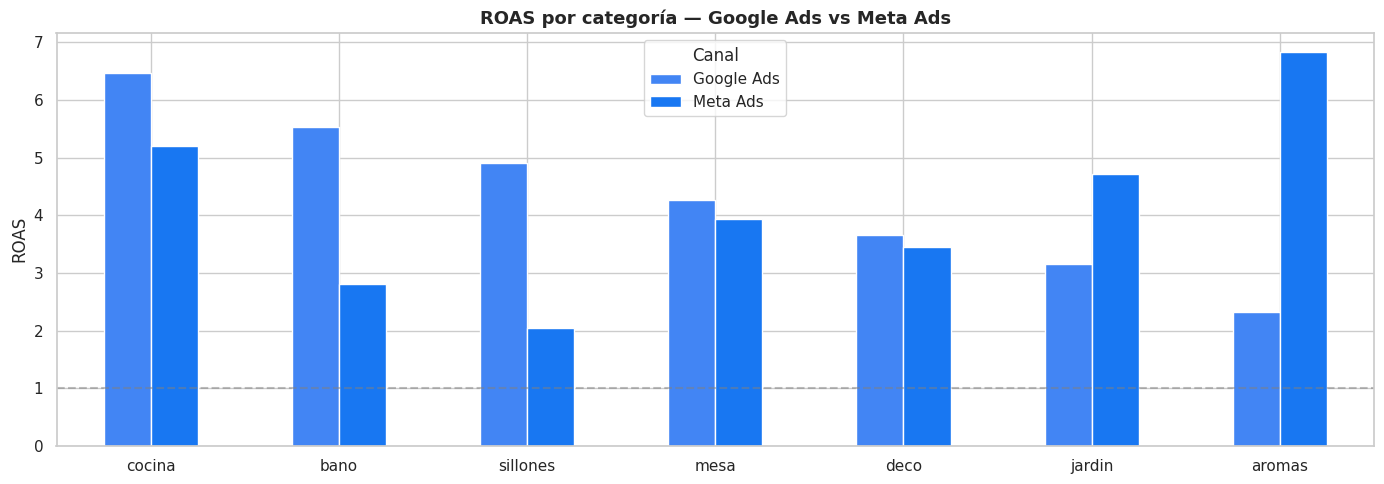

In [14]:
fig, ax = plt.subplots(figsize=(14, 5))
pivot_roas = by_campaign.pivot(index="campaign", columns="channel", values="roas").sort_values("Google Ads", ascending=False)
pivot_roas.plot(kind="bar", ax=ax, color=["#4285F4", "#1877F2"])
ax.set_title("ROAS por categoría — Google Ads vs Meta Ads", fontweight="bold")
ax.set_ylabel("ROAS"); ax.set_xlabel("")
ax.axhline(y=1, color="gray", linestyle="--", alpha=0.5)
ax.legend(title="Canal")
plt.xticks(rotation=0); plt.tight_layout()
plt.savefig(CHARTS_DIR / "03_roas_por_campana.png", dpi=120, bbox_inches="tight")
plt.show()

## 9. Cruce pauta ↔ ventas comerciales reales

Pregunta: ¿dónde está gastándose la pauta vs dónde realmente vende el negocio?

In [15]:
ventas_overlap = ventas[ventas["week_start"] >= OVERLAP_START].copy()
ventas_by_cat = ventas_overlap.groupby("categoria").agg(
    unidades=("unidades_vendidas", "sum"),
    revenue_real=("ingreso_total", "sum"),
).reset_index().rename(columns={"categoria": "campaign"})

pauta_by_cat = master_overlap.groupby("campaign").agg(
    cost_total=("cost", "sum"),
    revenue_atribuido=("revenue", "sum"),
).reset_index()

cruce = pauta_by_cat.merge(ventas_by_cat, on="campaign", how="outer")
cruce["share_inversion"] = cruce["cost_total"] / cruce["cost_total"].sum() * 100
cruce["share_revenue_real"] = cruce["revenue_real"] / cruce["revenue_real"].sum() * 100
cruce["gap_share"] = cruce["share_revenue_real"] - cruce["share_inversion"]
cruce = cruce.round(2).sort_values("revenue_real", ascending=False)
print(cruce)

   campaign  cost_total  revenue_atribuido  unidades   revenue_real  share_inversion  share_revenue_real  gap_share
6  sillones  812,322.95       2,907,181.00      6429 255,842,329.85            16.71               57.45      40.74
3      deco  907,442.27       3,229,996.40      6469  40,766,465.01            18.67                9.15      -9.51
4    jardin  673,427.26       2,616,571.22      6460  40,651,918.38            13.85                9.13      -4.72
1      bano  591,499.68       2,520,503.88      6107  35,857,662.91            12.17                8.05      -4.12
5      mesa  649,651.78       2,677,510.90      6578  26,313,824.68            13.36                5.91      -7.45
2    cocina  744,611.84       4,404,602.89      6355  25,933,948.26            15.32                5.82      -9.49
0    aromas  482,552.78       2,144,236.63      6460  19,985,566.38             9.93                4.49      -5.44


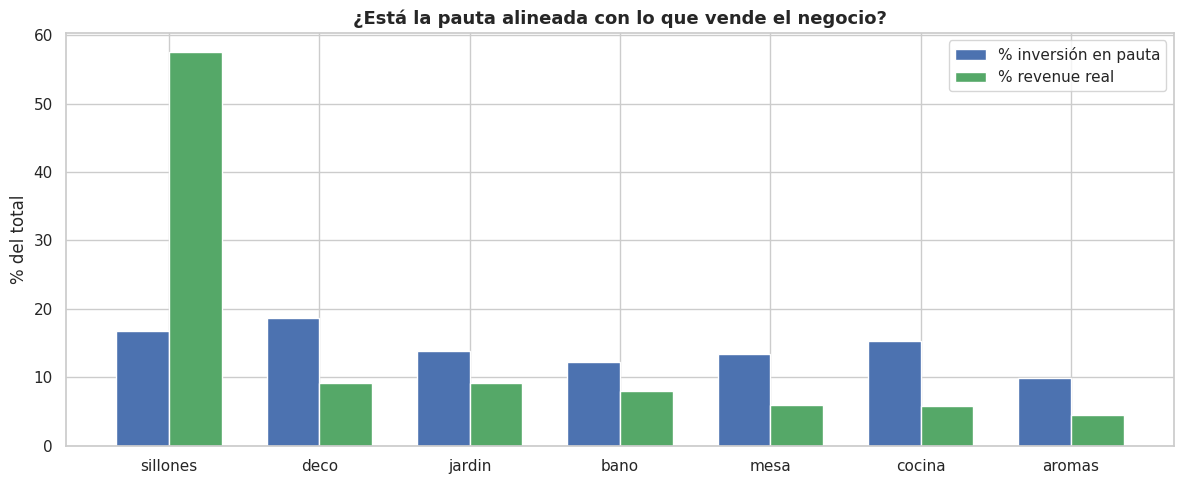

In [16]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(cruce))
w = 0.35
ax.bar(x - w/2, cruce["share_inversion"], w, label="% inversión en pauta", color="#4c72b0")
ax.bar(x + w/2, cruce["share_revenue_real"], w, label="% revenue real", color="#55a868")
ax.set_xticks(x); ax.set_xticklabels(cruce["campaign"], rotation=0)
ax.set_ylabel("% del total")
ax.set_title("¿Está la pauta alineada con lo que vende el negocio?", fontweight="bold")
ax.legend(); plt.tight_layout()
plt.savefig(CHARTS_DIR / "04_share_pauta_vs_ventas.png", dpi=120, bbox_inches="tight")
plt.show()

**Insight clave (titular más fuerte):**

Deco y Sillones reciben presupuestos de pauta similares (18.7% vs 16.7%), pero sus ventas son absolutamente distintas: Deco vende 9% del revenue total del negocio y Sillones vende 57%. Es decir, el negocio está pautando MÁS por Deco que por Sillones a pesar de que Sillones vende casi 6 veces más.

Esto sugiere una reasignación de presupuesto: mover pauta desde Deco/Cocina/Jardín/Baño hacia Sillones.

## 9.1 AOV (ticket promedio) y top productos individuales

La mirada por categoría oculta información útil. Con AOV y un top por producto entendemos **por qué** sillones domina el revenue (no es que vende muchas más unidades — es que el AOV es 10x) y vemos si el negocio depende de pocos SKU "estrella".

In [17]:
# AOV (ticket promedio) por categoría
aov_cat = (
    ventas.groupby("categoria")
    .apply(lambda d: d["ingreso_total"].sum() / d["unidades_vendidas"].sum(),
           include_groups=False)
    .sort_values(ascending=False)
    .reset_index(name="aov")
)
print("AOV (precio promedio por unidad) por categoría:")
print(aov_cat)

AOV (precio promedio por unidad) por categoría:
  categoria       aov
0  sillones 39,795.04
1      deco  6,301.82
2    jardin  6,292.87
3      bano  5,871.57
4    cocina  4,080.87
5      mesa  4,000.28
6    aromas  3,093.74


In [18]:
# Top 10 productos individuales por revenue acumulado
top_productos = (
    ventas.groupby(["producto", "categoria"])
    .agg(revenue_total=("ingreso_total", "sum"),
         unidades_total=("unidades_vendidas", "sum"))
    .assign(precio_unit=lambda d: d["revenue_total"] / d["unidades_total"])
    .sort_values("revenue_total", ascending=False)
    .head(10)
    .reset_index()
)
print("\nTOP 10 PRODUCTOS POR REVENUE ACUMULADO (período 2025-2026):")
print(top_productos.round(0))


TOP 10 PRODUCTOS POR REVENUE ACUMULADO (período 2025-2026):
                    producto categoria  revenue_total  unidades_total  precio_unit
0    Sillón Terciopelo Verde  sillones  85,265,930.00            1610    52,960.00
1          Sillón Boho Arena  sillones  78,146,915.00            1597    48,934.00
2      Sillón Acapulco Negro  sillones  54,047,370.00            1516    35,651.00
3        Puff Redondo Boucle  sillones  38,382,115.00            1706    22,498.00
4     Espejo Redondo Nordico      bano  18,211,937.00            1501    12,133.00
5     Estante Flotante Roble      deco  14,664,509.00            1615     9,080.00
6     Regadera Cobre Vintage    jardin  13,929,420.00            1723     8,084.00
7        Maceta Terracota XL    jardin  11,328,633.00            1632     6,942.00
8         Set Toallas Waffle      bano  10,404,097.00            1574     6,610.00
9  Jarrón Minimalista Blanco      deco  10,217,047.00            1614     6,330.00


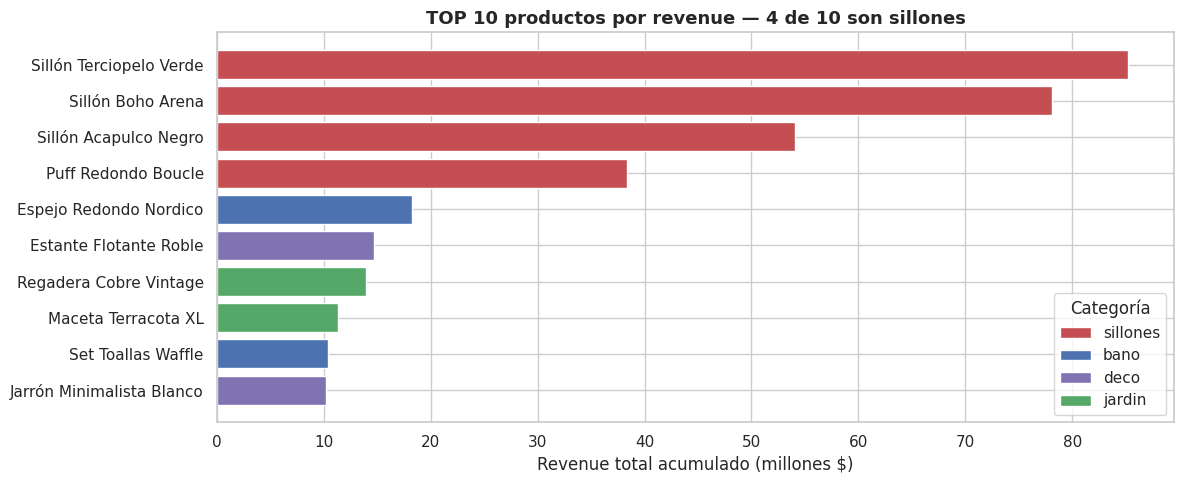

In [19]:
# Chart: top 10 productos con color por categoría
from matplotlib.patches import Patch
fig, ax = plt.subplots(figsize=(12, 5))
cat_colors = {"sillones": "#c44e52", "bano": "#4c72b0", "deco": "#8172b2",
              "jardin": "#55a868", "cocina": "#dd8452", "mesa": "#da8bc3", "aromas": "#937860"}
colors = [cat_colors.get(c, "#888") for c in top_productos["categoria"]]
ax.barh(top_productos["producto"][::-1], top_productos["revenue_total"][::-1] / 1e6,
        color=colors[::-1])
ax.set_xlabel("Revenue total acumulado (millones $)")
ax.set_title("TOP 10 productos por revenue — 4 de 10 son sillones", fontweight="bold")
legend_elements = [Patch(facecolor=cat_colors[c], label=c)
                   for c in top_productos["categoria"].unique() if c in cat_colors]
ax.legend(handles=legend_elements, loc="lower right", title="Categoría")
plt.tight_layout()
plt.savefig(CHARTS_DIR / "09_top_productos.png", dpi=120, bbox_inches="tight")
plt.show()

**Lectura clave:**

- **Sillones tiene AOV ~$40K, 10x más caro que el promedio** ($3K aromas, $4K cocina/mesa). Por eso domina el revenue total del negocio aunque no vende tantas más unidades.
- **4 de los top 10 productos son sillones**, concentrando ~$256M de revenue acumulado.
- **Implicancia para la pauta**: un click convertido en sillones vale ~13x más que uno en aromas. Una campaña de sillones puede tolerar CPCs mucho más altos antes de volverse ineficiente.

## 10. Eficiencia por click — ¿qué campañas rinden mejor por cada peso en click?

Scatter de CPC vs ROAS por canal × campaña. Cada punto es un combo específico. El tamaño del punto es la inversión total (cuán "grande" es la campaña).

- **Cuadrante superior izquierdo** (CPC bajo, ROAS alto) → campañas eficientes que conviene escalar.
- **Cuadrante superior derecho** (CPC alto, ROAS alto) → campañas caras pero valiosas; el costo vale la pena.
- **Cuadrante inferior izquierdo** (CPC bajo, ROAS bajo) → clicks baratos pero que no convierten; problema en landing/producto.
- **Cuadrante inferior derecho** (CPC alto, ROAS bajo) → peor escenario, hay que optimizar o pausar.

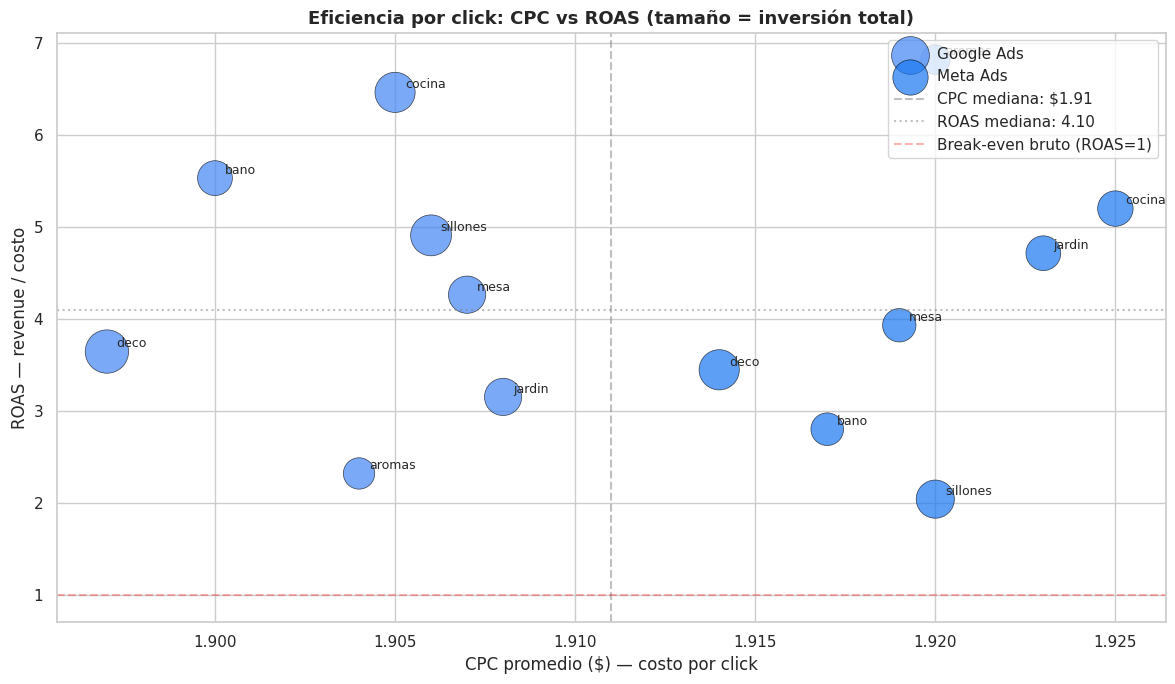

In [20]:
fig, ax = plt.subplots(figsize=(12, 7))
colors = {"Google Ads": "#4285F4", "Meta Ads": "#1877F2"}
for ch, grp in by_campaign.groupby("channel"):
    ax.scatter(grp["cpc"], grp["roas"],
               s=grp["cost"] / 500, alpha=0.7,
               label=ch, color=colors[ch], edgecolor="black", linewidth=0.5)
    for _, row in grp.iterrows():
        ax.annotate(row["campaign"], (row["cpc"], row["roas"]),
                    xytext=(7, 3), textcoords="offset points", fontsize=9)

median_cpc = by_campaign["cpc"].median()
median_roas = by_campaign["roas"].median()
ax.axvline(median_cpc, color="gray", linestyle="--", alpha=0.5, label=f"CPC mediana: ${median_cpc:.2f}")
ax.axhline(median_roas, color="gray", linestyle=":", alpha=0.5, label=f"ROAS mediana: {median_roas:.2f}")
ax.axhline(1, color="red", linestyle="--", alpha=0.3, label="Break-even bruto (ROAS=1)")
ax.set_xlabel("CPC promedio ($) — costo por click")
ax.set_ylabel("ROAS — revenue / costo")
ax.set_title("Eficiencia por click: CPC vs ROAS (tamaño = inversión total)", fontweight="bold")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig(CHARTS_DIR / "05_eficiencia_cpc_roas.png", dpi=120, bbox_inches="tight")
plt.show()

In [21]:
# Tabla de eficiencia ranqueada por ROAS
eficiencia = by_campaign.sort_values("roas", ascending=False)[
    ["channel", "campaign", "cost", "clicks", "cpc", "roas", "revenue"]
].reset_index(drop=True)
eficiencia["cost_pct_total"] = (eficiencia["cost"] / eficiencia["cost"].sum() * 100).round(1)
print("Ranking de eficiencia (canal × campaña, ordenado por ROAS desc):")
print(eficiencia)

Ranking de eficiencia (canal × campaña, ordenado por ROAS desc):
       channel  campaign       cost  clicks  cpc  roas      revenue  cost_pct_total
0     Meta Ads    aromas 227,168.99  118313 1.92  6.82 1,550,267.63            4.70
1   Google Ads    cocina 418,631.82  219802 1.91  6.47 2,707,717.70            8.60
2   Google Ads      bano 315,145.79  165895 1.90  5.54 1,744,722.25            6.50
3     Meta Ads    cocina 325,980.02  169330 1.93  5.21 1,696,885.19            6.70
4   Google Ads  sillones 434,153.38  227749 1.91  4.91 2,133,222.82            8.90
5     Meta Ads    jardin 313,657.01  163081 1.92  4.72 1,480,307.62            6.50
6   Google Ads      mesa 360,307.50  188894 1.91  4.27 1,538,325.13            7.40
7     Meta Ads      mesa 289,344.28  150789 1.92  3.94 1,139,185.77            6.00
8   Google Ads      deco 487,724.66  257167 1.90  3.65 1,780,590.45           10.00
9     Meta Ads      deco 419,717.61  219273 1.91  3.45 1,449,405.95            8.60
10  Google 

## 11. Estacionalidad con calendario comercial argentino

Hike vende en Argentina. Las fechas comerciales clave del ecommerce local son:
- **Hot Sale** (mayo, tres días)
- **Día del Padre** (tercer domingo de junio)
- **Día del Amigo** (20 de julio)
- **Día del Niño** (tercer domingo de agosto)
- **Día de la Madre** (tercer domingo de octubre)
- **Black Friday / Cyber Monday** (fin de noviembre)
- **Navidad / fin de año** (fin de diciembre)

Armo un calendario con las fechas y las cruzo contra el revenue semanal para ver si coinciden los picos.

In [22]:
# Calendario comercial AR para 2025 y 2026 (mapeado a la semana lunes de esa fecha)
def week_of(date_str):
    """Devuelve el lunes de la semana que contiene la fecha."""
    d = pd.Timestamp(date_str)
    return d - pd.Timedelta(days=d.weekday())

calendario_ar = pd.DataFrame([
    # 2025
    ("2025-05-12", "Hot Sale", 2025),
    ("2025-06-15", "Día del Padre", 2025),
    ("2025-07-20", "Día del Amigo", 2025),
    ("2025-08-17", "Día del Niño", 2025),
    ("2025-10-19", "Día de la Madre", 2025),
    ("2025-11-28", "Black Friday", 2025),
    ("2025-12-01", "Cyber Monday", 2025),
    ("2025-12-25", "Navidad", 2025),
    # 2026
    ("2026-05-11", "Hot Sale", 2026),
    ("2026-06-21", "Día del Padre", 2026),
    ("2026-07-20", "Día del Amigo", 2026),
    ("2026-08-16", "Día del Niño", 2026),
    ("2026-10-18", "Día de la Madre", 2026),
    ("2026-11-27", "Black Friday", 2026),
    ("2026-11-30", "Cyber Monday", 2026),
    ("2026-12-25", "Navidad", 2026),
], columns=["fecha", "evento", "anio"])
calendario_ar["semana"] = calendario_ar["fecha"].apply(week_of)
print(calendario_ar)

         fecha           evento  anio     semana
0   2025-05-12         Hot Sale  2025 2025-05-12
1   2025-06-15    Día del Padre  2025 2025-06-09
2   2025-07-20    Día del Amigo  2025 2025-07-14
3   2025-08-17     Día del Niño  2025 2025-08-11
4   2025-10-19  Día de la Madre  2025 2025-10-13
5   2025-11-28     Black Friday  2025 2025-11-24
6   2025-12-01     Cyber Monday  2025 2025-12-01
7   2025-12-25          Navidad  2025 2025-12-22
8   2026-05-11         Hot Sale  2026 2026-05-11
9   2026-06-21    Día del Padre  2026 2026-06-15
10  2026-07-20    Día del Amigo  2026 2026-07-20
11  2026-08-16     Día del Niño  2026 2026-08-10
12  2026-10-18  Día de la Madre  2026 2026-10-12
13  2026-11-27     Black Friday  2026 2026-11-23
14  2026-11-30     Cyber Monday  2026 2026-11-30
15  2026-12-25          Navidad  2026 2026-12-21


In [23]:
# Revenue semanal total del negocio
weekly_sales = ventas.groupby("week_start")["ingreso_total"].sum().reset_index()
weekly_sales.columns = ["week", "revenue_real"]

# Revenue semanal por canal de pauta
weekly_pauta = master_ads.groupby("week").agg(cost=("cost", "sum"), revenue_atribuido=("revenue", "sum")).reset_index()

# Top 10 semanas de revenue
top10 = weekly_sales.nlargest(10, "revenue_real")
top10["semana_str"] = top10["week"].dt.strftime("%Y-%m-%d")
# Matcheamos con eventos del calendario (con tolerancia de ±2 semanas)
def find_event(week):
    for _, row in calendario_ar.iterrows():
        delta = abs((row["semana"] - week).days)
        if delta <= 14:
            return row["evento"]
    return ""
top10["evento_cercano"] = top10["week"].apply(find_event)
print("TOP 10 SEMANAS DE MAYOR REVENUE REAL:")
print(top10[["semana_str", "revenue_real", "evento_cercano"]])

TOP 10 SEMANAS DE MAYOR REVENUE REAL:
     semana_str  revenue_real evento_cercano
96   2026-11-09  8,137,338.74   Black Friday
103  2026-12-28  8,018,323.02        Navidad
102  2026-12-21  7,627,173.00        Navidad
99   2026-11-30  7,491,619.89   Black Friday
98   2026-11-23  7,240,969.90   Black Friday
51   2025-12-29  7,014,386.70        Navidad
43   2025-11-03  6,977,007.04               
49   2025-12-15  6,877,585.61   Cyber Monday
97   2026-11-16  6,843,031.84   Black Friday
45   2025-11-17  6,775,030.42   Black Friday


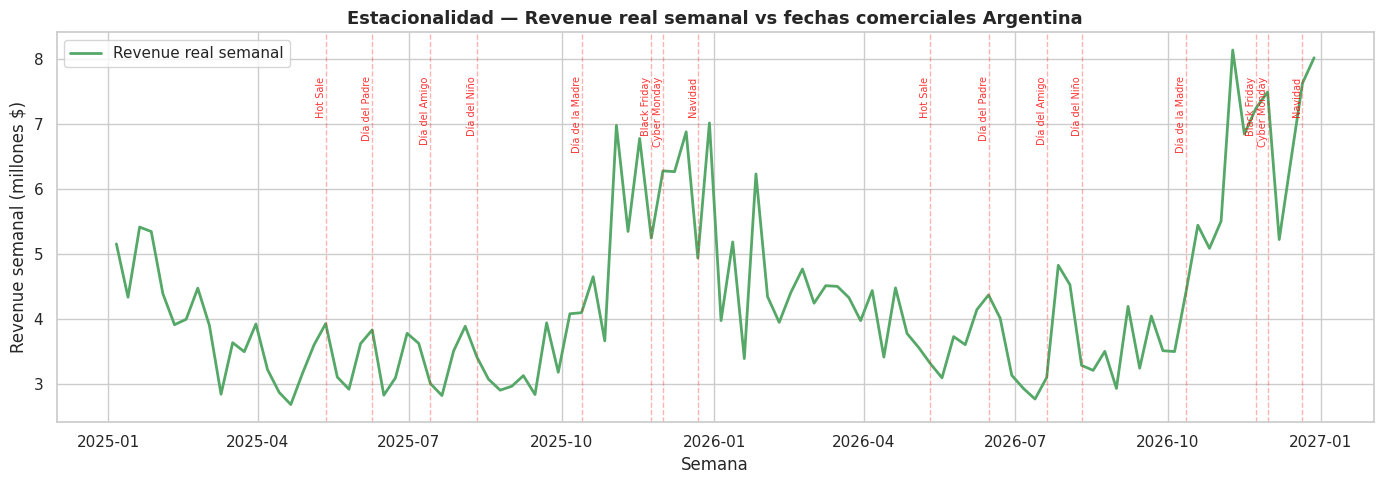

In [24]:
# Visualización: revenue semanal con eventos comerciales marcados
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(weekly_sales["week"], weekly_sales["revenue_real"] / 1_000_000, color="#55a868", linewidth=2, label="Revenue real semanal")

# Marcar eventos
y_max = weekly_sales["revenue_real"].max() / 1_000_000
for _, ev in calendario_ar.iterrows():
    ax.axvline(x=ev["semana"], color="red", alpha=0.3, linestyle="--", linewidth=1)
    ax.annotate(ev["evento"], xy=(ev["semana"], y_max * 0.95),
                rotation=90, fontsize=7, ha="right", va="top", color="red", alpha=0.8)

ax.set_xlabel("Semana")
ax.set_ylabel("Revenue semanal (millones $)")
ax.set_title("Estacionalidad — Revenue real semanal vs fechas comerciales Argentina", fontweight="bold")
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig(CHARTS_DIR / "06_estacionalidad.png", dpi=120, bbox_inches="tight")
plt.show()

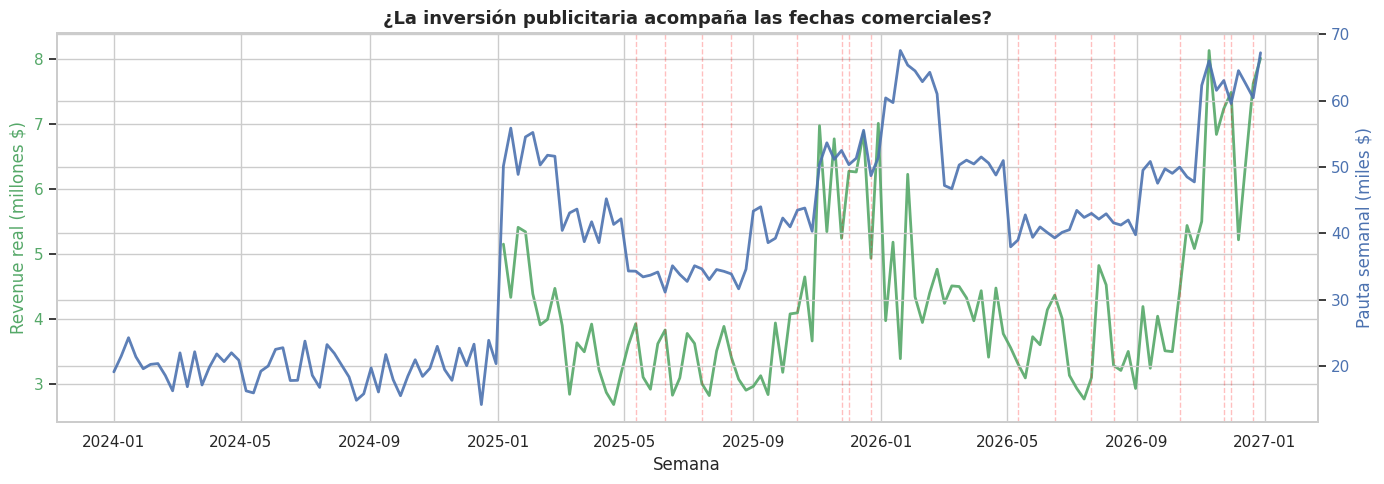

In [25]:
# Comparar: ¿la pauta acompaña las fechas comerciales?
fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(weekly_sales["week"], weekly_sales["revenue_real"] / 1_000_000,
         color="#55a868", linewidth=2, label="Revenue real (M $)", alpha=0.9)
ax1.set_xlabel("Semana"); ax1.set_ylabel("Revenue real (millones $)", color="#55a868")
ax1.tick_params(axis="y", labelcolor="#55a868")

ax2 = ax1.twinx()
ax2.plot(weekly_pauta["week"], weekly_pauta["cost"] / 1000,
         color="#4c72b0", linewidth=2, label="Pauta total (miles $)", alpha=0.9)
ax2.set_ylabel("Pauta semanal (miles $)", color="#4c72b0")
ax2.tick_params(axis="y", labelcolor="#4c72b0")

for _, ev in calendario_ar.iterrows():
    ax1.axvline(x=ev["semana"], color="red", alpha=0.25, linestyle="--", linewidth=1)

ax1.set_title("¿La inversión publicitaria acompaña las fechas comerciales?", fontweight="bold")
plt.tight_layout()
plt.savefig(CHARTS_DIR / "07_pauta_vs_estacionalidad.png", dpi=120, bbox_inches="tight")
plt.show()

## 12. Historia completa de Google Ads (2024-2026)

Google tiene un año más de data que Meta. Lo aprovechamos para ver:
- Evolución anual de inversión y revenue atribuido.
- Estacionalidad mensual (patrones que se repiten año a año).
- ¿Cambió Google cuando entró Meta en 2025?

In [26]:
g_all = master_ads[master_ads["channel"] == "Google Ads"].copy()
g_all["anio"] = g_all["week"].dt.year
g_all["mes"] = g_all["week"].dt.month

anual_google = g_all.groupby("anio").agg(
    cost=("cost", "sum"),
    impressions=("impressions", "sum"),
    clicks=("clicks", "sum"),
    revenue=("revenue", "sum"),
).assign(
    cpc=lambda d: d["cost"] / d["clicks"],
    roas=lambda d: d["revenue"] / d["cost"],
).round(2)
print("Google Ads — KPIs anuales:")
print(anual_google)

Google Ads — KPIs anuales:
             cost  impressions  clicks      revenue  cpc  roas
anio                                                          
2024 1,044,065.36     26715672  488487 4,896,102.64 2.14  4.69
2025 1,176,917.60     31921667  617511 5,211,562.93 1.91  4.43
2026 1,454,199.59     39432086  764706 6,423,248.02 1.90  4.42


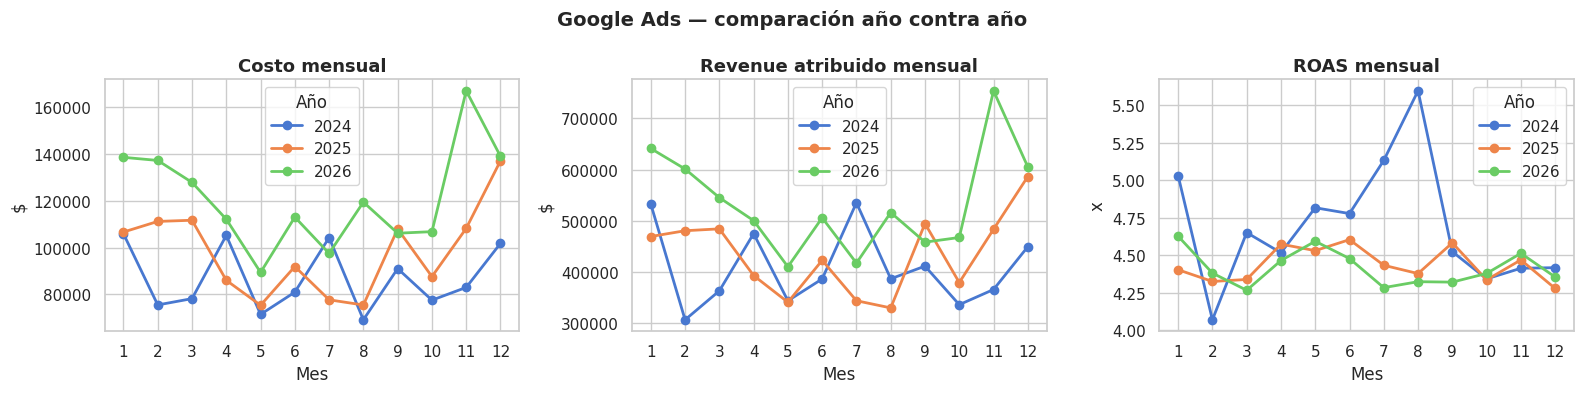

In [27]:
# Evolución mensual de Google (las 3 cohortes anuales superpuestas)
g_monthly = g_all.groupby(["anio", "mes"]).agg(
    cost=("cost", "sum"), revenue=("revenue", "sum")
).assign(roas=lambda d: d["revenue"] / d["cost"]).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for anio, grp in g_monthly.groupby("anio"):
    axes[0].plot(grp["mes"], grp["cost"], marker="o", label=str(anio), linewidth=2)
    axes[1].plot(grp["mes"], grp["revenue"], marker="o", label=str(anio), linewidth=2)
    axes[2].plot(grp["mes"], grp["roas"], marker="o", label=str(anio), linewidth=2)

for i, (title, ylabel) in enumerate([("Costo mensual", "$"), ("Revenue atribuido mensual", "$"), ("ROAS mensual", "x")]):
    axes[i].set_title(title)
    axes[i].set_xlabel("Mes")
    axes[i].set_ylabel(ylabel)
    axes[i].set_xticks(range(1, 13))
    axes[i].legend(title="Año")

plt.suptitle("Google Ads — comparación año contra año", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(CHARTS_DIR / "08_google_historico.png", dpi=120, bbox_inches="tight")
plt.show()

In [28]:
# ¿Cambió Google cuando entró Meta en 2025?
g_pre_meta = g_all[g_all["week"] < OVERLAP_START]  # solo 2024
g_post_meta = g_all[g_all["week"] >= OVERLAP_START]  # 2025-2026
print("ANTES DE META (2024):")
print(f"  Cost: ${g_pre_meta['cost'].sum():,.0f}")
print(f"  Revenue: ${g_pre_meta['revenue'].sum():,.0f}")
print(f"  ROAS: {g_pre_meta['revenue'].sum() / g_pre_meta['cost'].sum():.2f}")
print(f"  CPC promedio: ${g_pre_meta['cost'].sum() / g_pre_meta['clicks'].sum():.2f}")

print("\nDESPUÉS DE META (2025-2026):")
print(f"  Cost: ${g_post_meta['cost'].sum():,.0f}")
print(f"  Revenue: ${g_post_meta['revenue'].sum():,.0f}")
print(f"  ROAS: {g_post_meta['revenue'].sum() / g_post_meta['cost'].sum():.2f}")
print(f"  CPC promedio: ${g_post_meta['cost'].sum() / g_post_meta['clicks'].sum():.2f}")

ANTES DE META (2024):
  Cost: $1,044,065
  Revenue: $4,896,103
  ROAS: 4.69
  CPC promedio: $2.14

DESPUÉS DE META (2025-2026):
  Cost: $2,631,117
  Revenue: $11,634,811
  ROAS: 4.42
  CPC promedio: $1.90


## 13. Stock + alertas de negocio

In [29]:
unique_weeks = sorted(ventas["week_start"].unique())
last_12_weeks = unique_weeks[-12:]
recent = ventas[ventas["week_start"].isin(last_12_weeks)].copy()
N_WEEKS_WINDOW = len(last_12_weeks)  # = 12, por construcción

rotacion = recent.groupby("producto").agg(
    unidades_12w=("unidades_vendidas", "sum"),
    revenue_12w=("ingreso_total", "sum"),
).reset_index()
rotacion["ventas_semanales_prom"] = rotacion["unidades_12w"] / N_WEEKS_WINDOW

alerta_stock = stock.merge(rotacion, on="producto", how="left").fillna(0)
alerta_stock["semanas_stock_cubre"] = alerta_stock["stock"] / alerta_stock["ventas_semanales_prom"].replace(0, np.nan)
alerta_stock["alerta"] = np.where(
    alerta_stock["semanas_stock_cubre"] < 4,
    "🔴 Stock crítico (<4 semanas)",
    np.where(
        alerta_stock["semanas_stock_cubre"] > 52,
        "🟡 Stock ocioso (>1 año)",
        "🟢 OK"
    )
)

print("TOP 10 PRODUCTOS EN ALERTA DE STOCK:")
top_riesgo = alerta_stock[alerta_stock["alerta"].str.contains("crítico")] \
    .sort_values("revenue_12w", ascending=False).head(10)
print(top_riesgo[["producto", "categoria", "stock", "ventas_semanales_prom", "semanas_stock_cubre", "revenue_12w"]])

TOP 10 PRODUCTOS EN ALERTA DE STOCK:
                     producto categoria  stock  ventas_semanales_prom  semanas_stock_cubre   revenue_12w
18          Sillón Boho Arena  sillones     18                  25.25                 0.71 14,922,350.60
19    Sillón Terciopelo Verde  sillones     12                  20.42                 0.59 12,893,197.00
21      Sillón Acapulco Negro  sillones     22                  22.92                 0.96  9,959,194.56
20        Puff Redondo Boucle  sillones     34                  23.17                 1.47  6,222,729.92
9      Espejo Redondo Nordico      bano     28                  24.25                 1.15  3,598,191.92
15     Estante Flotante Roble      deco     36                  25.92                 1.39  2,868,899.92
36     Regadera Cobre Vintage    jardin     35                  25.08                 1.40  2,434,563.10
7          Set Toallas Waffle      bano     55                  24.92                 2.21  2,010,210.38
33        Maceta T

In [30]:
# % del revenue total (exactamente últimas 12 semanas) que viene de productos en alerta crítica
rev_12w_total = recent["ingreso_total"].sum()  # recent = ya filtrado a las últimas 12 semanas
productos_criticos_list = alerta_stock[alerta_stock["alerta"].str.contains("crítico")]["producto"].tolist()
rev_12w_alerta = recent[recent["producto"].isin(productos_criticos_list)]["ingreso_total"].sum()
pct_revenue_en_riesgo = rev_12w_alerta / rev_12w_total * 100
print(f"\nRevenue de últimas 12 semanas en productos con stock crítico: ${rev_12w_alerta:,.0f}")
print(f"Sobre revenue total 12 semanas: ${rev_12w_total:,.0f}")
print(f"→ {pct_revenue_en_riesgo:.1f}% del revenue reciente está en productos con stock <4 semanas.")


Revenue de últimas 12 semanas en productos con stock crítico: $67,837,490
Sobre revenue total 12 semanas: $77,458,364
→ 87.6% del revenue reciente está en productos con stock <4 semanas.


## 13.1 Productos zombie — catálogo inactivo

Cruzando stock contra ventas: ¿hay productos cargados en el catálogo que nunca aparecieron en ventas? Es capital de trabajo inmovilizado.

In [31]:
prods_vendidos = set(ventas["producto"].unique())
zombies = stock[~stock["producto"].isin(prods_vendidos)].copy()
zombies = zombies[["producto", "sku", "stock", "categoria"]].sort_values("stock", ascending=False).reset_index(drop=True)

print(f"PRODUCTOS EN STOCK QUE NUNCA APARECIERON EN VENTAS: {len(zombies)}")
print(zombies)
print(f"\nStock inmovilizado total: {zombies['stock'].sum()} unidades")

dist_zombies = zombies.groupby("categoria")["stock"].agg(productos="count", unidades="sum").sort_values("unidades", ascending=False)
print("\nDistribución por categoría:")
print(dist_zombies)

PRODUCTOS EN STOCK QUE NUNCA APARECIERON EN VENTAS: 10
                      producto      sku  stock categoria
0   Salvamanteles Silicona Set  COC-006    210    cocina
1      Salero Pimentero Madera  MES-005    124      mesa
2       Guirnalda LED Solar 5m  JAR-005     97    jardin
3   Dispensador Jabón Terrazzo  BAN-006     89      bano
4    Aceite Esencial Eucalipto  ARO-005     88    aromas
5           Cesto Mimbre Rollo  BAN-005     67      bano
6       Colgador Pared Macramé  DEC-006     57      deco
7      Reloj Pared Minimalista  DEC-005     49      deco
8  Especiero Madera 12 frascos  COC-005     43    cocina
9         Silla Ratán Exterior  SIL-005     40  sillones

Stock inmovilizado total: 864 unidades

Distribución por categoría:
           productos  unidades
categoria                     
cocina             2       253
bano               2       156
mesa               1       124
deco               2       106
jardin             1        97
aromas             1        88
s

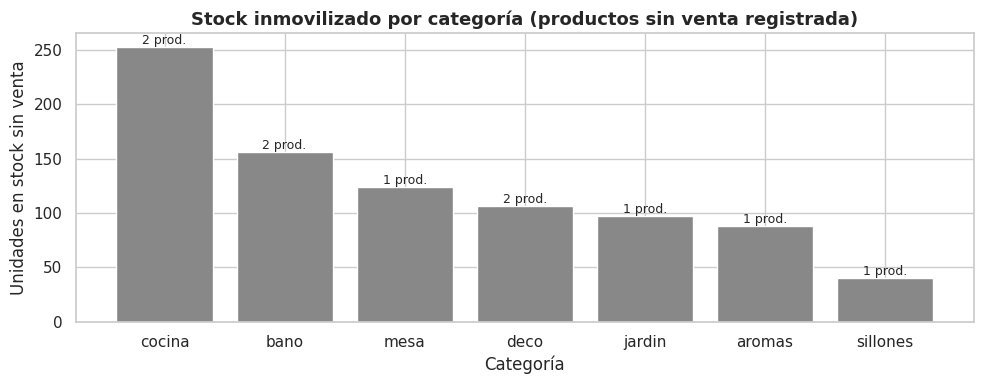

In [32]:
# Chart: zombies por categoría
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(dist_zombies.index, dist_zombies["unidades"], color="#888888")
for i, (cat, row) in enumerate(dist_zombies.iterrows()):
    ax.annotate(f"{int(row['productos'])} prod.", xy=(i, row["unidades"]),
                ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Unidades en stock sin venta")
ax.set_xlabel("Categoría")
ax.set_title("Stock inmovilizado por categoría (productos sin venta registrada)", fontweight="bold")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(CHARTS_DIR / "10_productos_zombie.png", dpi=120, bbox_inches="tight")
plt.show()

**Observación**: hay 10 productos (todos los SKU `-005` y `-006` de cada categoría) que figuran en stock pero nunca aparecieron en las ventas del período analizado. Posibles explicaciones:
- Productos nuevos aún no publicados o sin pauta asociada.
- Productos descontinuados que quedaron en inventario.
- Problemas de catalogación (imágenes, descripciones) que impiden la conversión.

**Acción sugerida**: revisar el catálogo y decidir por cada producto si se relanza con pauta, se liquida, o se discontinúa formalmente.

## 14. Resumen ejecutivo refinado

In [33]:
total_cost = master_overlap["cost"].sum()
total_revenue_attr = master_overlap["revenue"].sum()
global_roas = total_revenue_attr / total_cost
total_revenue_real = ventas_overlap["ingreso_total"].sum()
pct_ventas_cubiertas = total_revenue_attr / total_revenue_real * 100

roas_google = master_overlap.loc[master_overlap.channel == "Google Ads", "revenue"].sum() / master_overlap.loc[master_overlap.channel == "Google Ads", "cost"].sum()
roas_meta = master_overlap.loc[master_overlap.channel == "Meta Ads", "revenue"].sum() / master_overlap.loc[master_overlap.channel == "Meta Ads", "cost"].sum()

# CTR por canal
ctr_google = master_overlap.loc[master_overlap.channel == "Google Ads", "clicks"].sum() / master_overlap.loc[master_overlap.channel == "Google Ads", "impressions"].sum() * 100
ctr_meta = master_overlap.loc[master_overlap.channel == "Meta Ads", "clicks"].sum() / master_overlap.loc[master_overlap.channel == "Meta Ads", "impressions"].sum() * 100

mejor_campana = by_campaign.sort_values("roas", ascending=False).iloc[0]
peor_campana = by_campaign.sort_values("roas", ascending=True).iloc[0]

# Calculamos shares desde fuente original, sin doble redondeo
share_sillones_rev = ventas_overlap[ventas_overlap["categoria"] == "sillones"]["ingreso_total"].sum() / ventas_overlap["ingreso_total"].sum() * 100
_ma_over_sill = master_overlap[master_overlap["campaign"] == "sillones"]["cost"].sum()
_ma_over_deco = master_overlap[master_overlap["campaign"] == "deco"]["cost"].sum()
_ma_over_tot = master_overlap["cost"].sum()
share_sillones_inv = _ma_over_sill / _ma_over_tot * 100
share_deco_inv = _ma_over_deco / _ma_over_tot * 100

# AOV extremos
aov_sillones = ventas[ventas.categoria == "sillones"]["ingreso_total"].sum() / ventas[ventas.categoria == "sillones"]["unidades_vendidas"].sum()
aov_aromas = ventas[ventas.categoria == "aromas"]["ingreso_total"].sum() / ventas[ventas.categoria == "aromas"]["unidades_vendidas"].sum()

n_stock_critico = (alerta_stock["alerta"].str.contains("crítico")).sum()
n_zombies = len(zombies)
stock_zombies_units = zombies["stock"].sum()

# Correlaciones (caveat metodológico)
weekly_g = master_ads[master_ads.channel=="Google Ads"].groupby("week").agg(c=("cost","sum"), r=("revenue","sum"))
weekly_m = master_ads[master_ads.channel=="Meta Ads"].groupby("week").agg(c=("cost","sum"), r=("revenue","sum"))
corr_google = weekly_g.c.corr(weekly_g.r)
corr_meta = weekly_m.c.corr(weekly_m.r)

# Crecimiento YoY en ventas reales
rev_2025 = ventas[ventas.week_start.dt.year == 2025]["ingreso_total"].sum()
rev_2026 = ventas[ventas.week_start.dt.year == 2026]["ingreso_total"].sum()
yoy_growth = (rev_2026 / rev_2025 - 1) * 100

print("=" * 70)
print("RESUMEN EJECUTIVO — Hike caso práctico")
print("=" * 70)
print(f"\n📊 PERFORMANCE GLOBAL (período comparable 2025-01-06 → 2026-12-28)")
print(f"  Inversión total: ${total_cost:,.0f}")
print(f"  Revenue atribuido por plataformas: ${total_revenue_attr:,.0f}")
print(f"  ROAS global: {global_roas:.2f}x | Google: {roas_google:.2f}x | Meta: {roas_meta:.2f}x")

print(f"\n💰 REVENUE REAL DEL NEGOCIO")
print(f"  Revenue total ecommerce: ${total_revenue_real:,.0f}")
print(f"  Cobertura atribuida por pauta: {pct_ventas_cubiertas:.1f}%")
print(f"  → El ~{100-pct_ventas_cubiertas:.0f}% restante responde a ventas orgánicas, otros canales")
print(f"    no medidos, o efectos indirectos de la pauta fuera de la ventana de atribución.")

print(f"\n⚠️ INSIGHT #1 — Desalineación pauta vs ventas")
print(f"  Sillones: {share_sillones_rev:.1f}% del revenue real pero {share_sillones_inv:.1f}% de la inversión.")
print(f"  Deco: {share_deco_inv:.1f}% de la inversión — MÁS que Sillones, y Deco vende ~6x menos.")
print(f"  → Reasignar presupuesto desde Deco/Cocina/Jardín hacia Sillones.")

print(f"\n⚠️ INSIGHT #2 — Mix de canal por categoría importa")
print(f"  Mejor: {mejor_campana['channel']} — {mejor_campana['campaign']} (ROAS {mejor_campana['roas']:.2f})")
print(f"  Peor:  {peor_campana['channel']} — {peor_campana['campaign']} (ROAS {peor_campana['roas']:.2f})")
print(f"  → Google domina en productos de intención (sillones, cocina, baño, mesa);")
print(f"    Meta domina en productos visuales/impulso (aromas, jardín).")

print(f"\n⚠️ INSIGHT #3 — Concentración extrema por producto y AOV")
print(f"  Sillones tiene AOV de ${aov_sillones:,.0f} vs aromas ${aov_aromas:,.0f} (13x).")
print(f"  4 de los top 10 productos son sillones: explica por qué domina el revenue real.")
print(f"  → La pauta por sillones puede tolerar CPC más alto antes de volverse ineficiente.")

print(f"\n⚠️ INSIGHT #4 — Stock crítico y revenue en riesgo")
print(f"  {n_stock_critico} productos tienen stock para <4 semanas de venta.")
print(f"  Los 4 sillones top (la categoría estrella) tienen stock para 0.5-1.4 semanas.")
print(f"  → {pct_revenue_en_riesgo:.1f}% del revenue de las últimas 12 semanas está en productos con stock crítico.")

print(f"\n⚠️ INSIGHT #5 — Catálogo zombie")
print(f"  {n_zombies} productos nunca aparecieron en ventas, con {stock_zombies_units} unidades inmovilizadas.")
print(f"  Son todos los SKU -005 y -006 de cada categoría: patrón sospechoso (¿productos nuevos no lanzados?).")
print(f"  → Review de catálogo: liquidar, relanzar con pauta o discontinuar formalmente.")

print(f"\n⚠️ INSIGHT #6 — Estacionalidad comercial concentrada")
print(f"  9 de los 10 picos de revenue caen en Q4 (Black Friday + Navidad).")
print(f"  Día del Amigo, Día del Niño, Hot Sale no mueven la aguja.")
print(f"  Crecimiento ventas YoY 2025→2026: {yoy_growth:+.1f}%.")
print(f"  → Concentrar esfuerzos de pauta y stock en noviembre-diciembre.")

print(f"\n📏 CTR comparativo — Meta engancha más, Google convierte mejor")
print(f"  Google CTR: {ctr_google:.2f}% | Meta CTR: {ctr_meta:.2f}%")
print(f"  Meta tiene mejor engagement (más clicks por impresión) pero Google mejor ROAS.")

print(f"\n🔬 CAVEAT METODOLÓGICO — naturaleza de los datos")
print(f"  Correlación semanal cost↔revenue: Google r={corr_google:.3f} | Meta r={corr_meta:.3f}")
print(f"  Correlaciones >0.9 sugieren datos sintéticos con ROAS casi fijo + ruido.")
print(f"  En producción, un ROAS semanal tan estable no es realista; hay que chequear con cohorte.")
print(f"  Además: conv_value (Google) puede incluir leads; purchase_value (Meta) solo compras.")
print(f"  Las ventanas de atribución difieren (30d vs 7d) e inflan el ROAS de Google vs Meta.")

RESUMEN EJECUTIVO — Hike caso práctico

📊 PERFORMANCE GLOBAL (período comparable 2025-01-06 → 2026-12-28)
  Inversión total: $4,861,509
  Revenue atribuido por plataformas: $20,500,603
  ROAS global: 4.22x | Google: 4.42x | Meta: 3.97x

💰 REVENUE REAL DEL NEGOCIO
  Revenue total ecommerce: $445,351,715
  Cobertura atribuida por pauta: 4.6%
  → El ~95% restante responde a ventas orgánicas, otros canales
    no medidos, o efectos indirectos de la pauta fuera de la ventana de atribución.

⚠️ INSIGHT #1 — Desalineación pauta vs ventas
  Sillones: 57.4% del revenue real pero 16.7% de la inversión.
  Deco: 18.7% de la inversión — MÁS que Sillones, y Deco vende ~6x menos.
  → Reasignar presupuesto desde Deco/Cocina/Jardín hacia Sillones.

⚠️ INSIGHT #2 — Mix de canal por categoría importa
  Mejor: Meta Ads — aromas (ROAS 6.82)
  Peor:  Meta Ads — sillones (ROAS 2.05)
  → Google domina en productos de intención (sillones, cocina, baño, mesa);
    Meta domina en productos visuales/impulso (arom

## 15. Exportar datos limpios (4 archivos maestros)

In [34]:
# Preparamos los CSVs para Looker Studio con columnas/claves alineadas
# y una tabla adicional de calendario comercial.
#
# IMPORTANTE: redondeamos las métricas a 2 decimales para evitar problemas
# de parseo en Google Sheets con configuración regional argentina
# (donde el punto es separador de miles y la coma decimal).
# CTR se exporta como porcentaje (0-100) en lugar de fracción (0-1) por
# la misma razón y porque es más legible.

# 1) master_ads: duplicamos 'campaign' como 'categoria' para blendear con ventas
master_ads_export = master_ads.copy()
master_ads_export["categoria"] = master_ads_export["campaign"]
# Rounding compatible con locale AR
master_ads_export["cpc"] = master_ads_export["cpc"].round(2)
master_ads_export["cpm"] = master_ads_export["cpm"].round(2)
master_ads_export["ctr_pct"] = (master_ads_export["ctr"] * 100).round(2)  # porcentaje
master_ads_export["roas"] = master_ads_export["roas"].round(2)
# Reemplazamos la columna ctr fraccional por la versión en %
master_ads_export = master_ads_export.drop(columns=["ctr"]).rename(columns={"ctr_pct": "ctr"})
# Orden prolijo
master_ads_export = master_ads_export[["week", "channel", "campaign", "categoria",
                                         "cost", "impressions", "clicks", "revenue",
                                         "cpc", "cpm", "ctr", "roas"]]
master_ads_export.to_csv(CLEAN_DIR / "master_ads.csv", index=False,
                          decimal=",", sep=";")

# 2) ventas_clean: agregamos 'sku' (desde stock) y 'week' (duplicado de week_start) para blends
ventas_clean = ventas.copy()
ventas_clean = ventas_clean.merge(stock[["producto", "sku"]], on="producto", how="left")
ventas_clean["week"] = ventas_clean["week_start"]
ventas_clean["ingreso_total"] = ventas_clean["ingreso_total"].round(2)
ventas_clean = ventas_clean[["week", "week_start", "producto", "sku", "categoria",
                              "unidades_vendidas", "ingreso_total"]]
ventas_clean.to_csv(CLEAN_DIR / "ventas_clean.csv", index=False,
                     decimal=",", sep=";")

# 3) stock_clean: sin cambios
stock_clean = stock.copy()
stock_clean.to_csv(CLEAN_DIR / "stock_clean.csv", index=False,
                    decimal=",", sep=";")

# 4) alertas_stock: rounding de decimales largos + alerta_clean sin emoji
alerta_stock_export = alerta_stock.copy()
alerta_stock_export["ventas_semanales_prom"] = alerta_stock_export["ventas_semanales_prom"].round(2)
alerta_stock_export["semanas_stock_cubre"] = alerta_stock_export["semanas_stock_cubre"].round(2)
alerta_stock_export["revenue_12w"] = alerta_stock_export["revenue_12w"].round(2)
alerta_stock_export["alerta_clean"] = alerta_stock_export["alerta"].str.replace(
    r"[🔴🟡🟢]\s*", "", regex=True
)
alerta_stock_export.to_csv(CLEAN_DIR / "alertas_stock.csv", index=False,
                            decimal=",", sep=";")

# 5) calendario_ar: nueva tabla con fechas comerciales argentinas
calendario_ar.to_csv(CLEAN_DIR / "calendario_ar.csv", index=False,
                      decimal=",", sep=";")

# Limpiamos los exports anteriores que ya no usamos (si existen y si hay permiso)
for old_file in ["performance_por_campana.csv", "evolucion_semanal.csv",
                 "cruce_pauta_ventas.csv", "kpis_por_canal.csv"]:
    old_path = CLEAN_DIR / old_file
    if old_path.exists():
        try:
            old_path.unlink()
            print(f"Removido: {old_file}")
        except PermissionError:
            print(f"No se pudo borrar {old_file} (permiso) — eliminalo manualmente si querés.")

print("\n✅ ARCHIVOS MAESTROS EXPORTADOS:")
for f in sorted(CLEAN_DIR.glob("*.csv")):
    print(f"  - {f.name} ({f.stat().st_size / 1024:.1f} KB)")

print("\n✅ CHARTS GENERADOS:")
for f in sorted(CHARTS_DIR.glob("*.png")):
    print(f"  - {f.name}")


✅ ARCHIVOS MAESTROS EXPORTADOS:
  - alertas_stock.csv (3.8 KB)
  - calendario_ar.csv (0.7 KB)
  - master_ads.csv (146.9 KB)
  - stock_clean.csv (1.6 KB)
  - ventas_clean.csv (203.3 KB)

✅ CHARTS GENERADOS:
  - 01_overview_canales.png
  - 02_evolucion_semanal.png
  - 03_roas_por_campana.png
  - 04_share_pauta_vs_ventas.png
  - 05_eficiencia_cpc_roas.png
  - 06_estacionalidad.png
  - 07_pauta_vs_estacionalidad.png
  - 08_google_historico.png
  - 09_top_productos.png
  - 10_productos_zombie.png
